# DAT550 Final Project

## Music to note transcriptor
________________

# Summary

In this stage all files will be read, transformed and converted to its respective wave file.
Initially substantial features for each wave filewill be extracted and later on saved for ML training.

## Final project objective
To find the most suitable music notation model and evaluate different approaches.

## Data Preprocessing
- To choose among different feature extraction algorithms

## Algorithms to use

- [X] CNN Convolutional Neural Network
- [X] Transformers (From HugginFace)
- [ ] RNN-LSTM (Maybe)
- [ ] Classic classification approach
    - Random Forest
    - Naive Bayes 
 - MIDI Labels Extraction [Metadata] Tempo -> Convert whatever tempo into Second by second notes
     - Dataset Splitting
     - MidiSplit(filepath, chunks_per_sec, )
     - MidiLabel(chunk,number_of_tracks ) => Returns a vector with given notes per chunk
     MIDI_FILE [1 Chunk] -> [Wave]  -> Guess the most suitable note [B] 
         - Track 1 - Piano  -> A -> Intensity[1] - Pitch 
         - Track 2 - Drums  -> B -> Intensity [255]
         - TRack 3 - Guitar -> A -> Intensity
     Initial labels -- GroundTruth[] Training outpus 
     
     Feature Extraction - Average -> A
     
 - MIDI to Wave 
 - Wave to Spectrogram [Feature vector]
     - Feature Extraction
 - Test / Train model
 - Output Note per time [Second or millisecond] -> Append to a list
 - [- - - - - - - - - - - - - - - - - - - - - - - A - - - - B - - - - - A A A A A A A A G ]
 - Vector to MIDI
 - MIDI Labels Extraction [Metadata] Tempo -> Convert whatever tempo into Second by second notes
 - Evaluation
     - [X] MIDI Labels Extraction [Metadata] Tempo -> Convert whatever tempo into Second by second notes
     - [X] MIDI Labels Extraction [Metadata] Tempo -> Convert whatever tempo into Second by second notes
 
 - Transform the output of a vector back to MIDI
 
 


# Goal
- [X] Pretrained [Wav2Vec](https://huggingface.co/transformers/model_doc/wav2vec2.html) 
    - Baseline, From a given pretrained model, feed a set of expected features and evaluate its accuracy
- [X] Bootstrap
    - Based on different datasets:
        - MIDI poliphonic Sound files [Training model]
            - Data preprocessing +  CNN - 
        - MIDI poliphonic Sound files [Test model]
        - Complex melodies -- [Test model]
# Training
- Labeling the data - Midi notes extraction
- Song decomposition
- Spectrogram feature extraction
- CNN Model training

To try different Deep learning methods (Neural Network models) to evaluate the most accurate.


# Tasks

### Person 1 [Asahi]
- [x] Create function to open a MIDI File splitted in chunks
- [x] Create function to extract notes per MIDI file
- [ ] Split Spectrogram in time chunks
- [ ] CNN approach
- [ ] Data plotting

### Person 2 [Shaon]

- Model performance evaluation (Loss function)
- Wave2Vec HuggingFace - Transformer Model

### Person 3  [Lucas]
- Classical ML Methods
    - Bayes
    - Clustering
    - Or other

### Person 4 [Tim]
- [X] Create function to Convert MIDI to Wave
- [X] Basic Feature extraction (Wave2Spectrogram)
- Advanced Feature extraction functions
- Plot the number of principal components we use vs the variance of the samples


____________
- [ ]  RNN
- [ ] 
- [ ] Loss Functions




# Data Preprocessing

Select a series of MIDI files as datasources and convert them into time frames of 87 length size (Standard MIDI number of notes)
## Used Datasets
- https://www.kaggle.com/programgeek01/anime-music-midi
- https://www.kaggle.com/soumikrakshit/classical-music-midi

In [19]:
%pip install pretty_midi
%pip install mido
%pip install numpy
%pip install matplotlib
%pip install midi2audio
%pip install tqdm
%pip install --upgrade tensorflow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## PATHS
-> Edit to point to the locations on your computer

In [1]:
import os
import numpy as np
import tqdm


MIDI_SOUND_FONT = 'Soundfont/198_Yamaha_SY1_piano.sf2'

# This path should point to the used midi dataset
data_source_path = r"D:\Dev\datasets\midi\anime"

# This path has to be an existing folder on the disk, otherwise the files will not be created in the following
out_wav_path = r"D:\Dev\datasets\midi\out"

# Sample rate in Hz, common CD quality is 44100
SAMPLE_RATE = 16000

# Data Synthesis and Feature extraction
**The features are saved in a dictionary with the corresponding piece as key**
```Python
wave_files_dict[<wave_file_name>][0] # Mel Spectrogram
wave_files_dict[<wave_file_name>][1] # MFCC
wave_files_dict[<wave_file_name>][2] # CQT
wave_files_dict[<wave_file_name>][3] # Wave File Sample rate
wave_files_dict[<wave_file_name>][4] # Time array (measured in seconds and extracted from file sample rate)
```

In [4]:
from Utils import Midi
from  Utils import Feature
import importlib
import glob
importlib.reload(Midi)
importlib.reload(Feature)
mid_files_dict = Midi.get_midi_files(data_source_path, verbose=False)
features = list()
keys =  list(mid_files_dict.keys())  # Avoid exception when deleting keys
for key in tqdm.tqdm(keys):
    try:
        in_file = os.path.join(data_source_path, key)
        out_file = key.replace('.mid', '.wav')
        out_file = os.path.join(out_wav_path, out_file)
        Midi.midi2wave(in_file,out_file, sample_rate=SAMPLE_RATE)
        midi_time = mid_files_dict[key][0]
        midi_data = mid_files_dict[key][1]
        feature = Feature.Feature(midi_time, midi_data, out_file)
        features.append(feature)
    except (SystemError, FileNotFoundError) as e:
        ## Ignore files whose feature extraction has failed
        print(e)    

130it [00:15,  8.47it/s]
100%|████████████████████████████████████████████████████████████████████████████████| 130/130 [05:01<00:00,  2.32s/it]


In [5]:
features[0]

## Model training
### Creating training/test data and labels 

In [6]:
y = []
X_melspec = []
X_mfcc = []
X_cqt = []
X_time = []
X_audio_data = []
X_M2A = []

for feature in features:
    y.append(feature.Midi_Notes)
    X_audio_data.append(feature.Audio_data)
    X_time.append(feature.Audio_Time)
    X_melspec.append(feature.MelSpec)
    X_mfcc.append(feature.MFCC)
    X_M2A.append(feature.Midi_2_Audio_Time)
    X_cqt.append(feature.CQ)

In [7]:
# split the data in training and test sets
from sklearn.model_selection import train_test_split

TRAIN_SIZE = 0.6
TEST_SIZE = 0.2
VALIDATION_SIZE = 0.2

def train_test_validation_split(X, y):
    X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=TEST_SIZE+VALIDATION_SIZE)
    X_test, X_valid, y_test, y_valid = train_test_split(X_rest, y_rest, test_size=VALIDATION_SIZE/(TEST_SIZE+VALIDATION_SIZE))
    return X_train, X_test, X_valid, y_train, y_test, y_valid
    
X_melspec_train, X_melspec_test, X_melspec_valid, y_melspec_train, y_melspec_test, y_melspec_valid = train_test_validation_split(X_melspec, y)

X_mfcc_train, X_mfcc_test, X_mfcc_valid, y_mfcc_train, y_mfcc_test, y_mfcc_valid = train_test_validation_split(X_mfcc, y)

X_cqt_train, X_cqt_test, X_cqt_valid, y_cqt_train, y_cqt_test, y_cqt_valid = train_test_validation_split(X_cqt, y)

X_M2A_train, X_M2A_test, X_M2A_valid, y_M2A_train, y_M2A_test, y_M2A_valid = train_test_validation_split(X_M2A, y)


## Creating Functions to load and save pickle data

In [8]:
import pickle
def dump_pickle(file_name,data):
    path = os.path.join('Data',file_name)
    print(path)
    with open(path, 'wb') as file:
        pickle.dump(data, file)

def load_pickle(file_name):
    path = os.path.join('Data',file_name)
    print(path)
    with open(path, 'rb') as file:
        return pickle.load(file)   

## Save everything in pickle file to skip preprocessing next time

In [9]:
dump_pickle('mel_spec.pkl',(X_melspec_train, X_melspec_test, X_melspec_valid, y_melspec_train, y_melspec_test, y_melspec_valid))
dump_pickle('mfcc.pkl',(X_mfcc_train, X_mfcc_test, X_mfcc_valid, y_mfcc_train, y_mfcc_test, y_mfcc_valid))
dump_pickle('cqt.pkl',(X_cqt_train, X_cqt_test, X_cqt_valid, y_cqt_train, y_cqt_test, y_cqt_valid))
dump_pickle('m2a.pkl',(X_M2A_train, X_M2A_test, X_M2A_valid, y_M2A_train, y_M2A_test, y_M2A_valid))
dump_pickle('features.pkl',features)

Data\mel_spec.pkl
Data\mfcc.pkl
Data\cqt.pkl
Data\m2a.pkl
Data\features.pkl


## Load data from pickle file

In [88]:
(X_melspec_train, X_melspec_test, X_melspec_valid, y_melspec_train, y_melspec_test, y_melspec_valid) = load_pickle('mel_spec.pkl')
(X_mfcc_train, X_mfcc_test, X_mfcc_valid, y_mfcc_train, y_mfcc_test, y_mfcc_valid) = load_pickle('mfcc.pkl')
(X_cqt_train, X_cqt_test, X_cqt_valid, y_cqt_train, y_cqt_test, y_cqt_valid) = load_pickle('cqt.pkl')
(X_M2A_train, X_M2A_test, X_M2A_valid, y_M2A_train, y_M2A_test, y_M2A_valid) = load_pickle('m2a.pkl')
features = load_pickle('features.pkl')

## CNN Approach

In [11]:
f = features[0]
x = f.MFCC[f.Midi_2_Audio_Time[0]]
y = f.Midi_Notes[0]
#len(features[0].Midi_2_Audio_Time) # First 1/16 in MIDI Time
#features[0].MFCC.shape
#print(len(f.Midi_Notes), f.Total_Midi_time, f.Total_Audio_Time)

#f.MFCC[:,f.Midi_2_Audio_Time[-1]] # First MIDI CHUNK In Audio time
len(f.Midi_2_Audio_Time)
len(f.Midi_Notes)
#f.MelSpec.shape
#f.Total_Audio_Time
#f.MelSpec.shape[1]/f.Total_Audio_Time/16

2579

# Documentation

In [12]:
from matplotlib import pyplot as plt
import librosa.display

Melspectrogram

[Text(0.5, 1.0, 'Normalized log-power Mel-frequency spectrogram')]

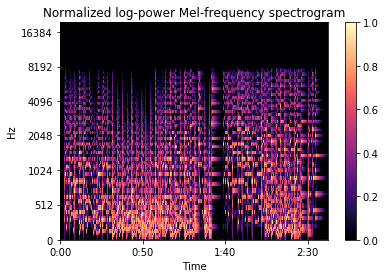

In [13]:
fig, ax = plt.subplots()
img = librosa.display.specshow(X_melspec[0], x_axis='time', y_axis='mel', sr=SAMPLE_RATE, fmax=20000, ax=ax)
fig.colorbar(img, ax=ax)
ax.set(title='Normalized log-power Mel-frequency spectrogram')

Mel-frequency cepstral coefficients (MFCCs)

[Text(0.5, 1.0, 'Normalized MFCC')]

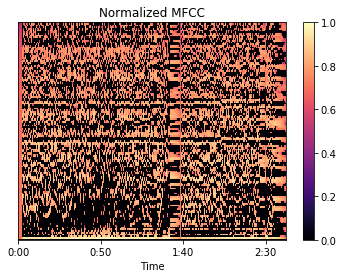

In [14]:
fig, ax = plt.subplots()
img = librosa.display.specshow(X_mfcc[0], x_axis='time', sr=SAMPLE_RATE, ax=ax)
fig.colorbar(img, ax=ax)
ax.set(title='Normalized MFCC')

constant-Q transform

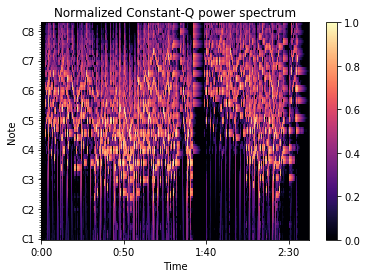

In [15]:
fig, ax = plt.subplots()
img = librosa.display.specshow(X_cqt[0], sr=SAMPLE_RATE, x_axis='time', y_axis='cqt_note', ax=ax)
ax.set_title('Normalized Constant-Q power spectrum')
fig.colorbar(img, ax=ax)

### Dimensionality reduction

## PCA

Mel Spectrogram

In [16]:
from sklearn.decomposition import PCA
pca = PCA(n_components=50) 
pca_ms = pca.fit_transform(X_melspec[0].T)
ms_explained_var = pca.explained_variance_ratio_
print(ms_explained_var)

[0.32018304 0.12046253 0.07426264 0.059795   0.05431521 0.03205039
 0.03022536 0.02642506 0.02466562 0.02035594 0.01997221 0.01669388
 0.01563424 0.01438633 0.01257273 0.0118757  0.01019199 0.00932304
 0.00807096 0.00794026 0.00715371 0.00610844 0.00593147 0.0054982
 0.00516068 0.00490875 0.00470736 0.00429305 0.00427255 0.00374889
 0.00359728 0.00347096 0.00322532 0.00313273 0.0029135  0.00257875
 0.00236808 0.00224157 0.00203607 0.00196776 0.00173937 0.00169747
 0.00164235 0.00146541 0.00142784 0.00132227 0.00123903 0.00106166
 0.00102771 0.00099623]


MFCC

In [17]:
pca = PCA(n_components=50) 
pca_mfcc = pca.fit_transform(X_mfcc[0].T)
mfcc_explained_var = pca.explained_variance_ratio_
print(mfcc_explained_var)

[0.08993893 0.06576692 0.06028834 0.04208731 0.0366611  0.03426651
 0.030907   0.02828108 0.02437573 0.02362242 0.02213834 0.02117827
 0.01864534 0.01725746 0.01567977 0.01456978 0.01421612 0.01314044
 0.01263501 0.01197121 0.01164808 0.01152423 0.01074883 0.01019326
 0.00997787 0.00962909 0.00943379 0.00887696 0.0085204  0.00813244
 0.00810289 0.00774033 0.00754875 0.00737685 0.00707198 0.00676297
 0.00654778 0.00637933 0.00618779 0.00608569 0.0058737  0.00566753
 0.00560507 0.0054641  0.00521344 0.005175   0.00499778 0.00491261
 0.00479571 0.00478308]


CQT

In [22]:
pca = PCA(n_components=50) 
pca_cqt = pca.fit_transform(X_cqt[0].T)
cqt_explained_var = pca.explained_variance_ratio_
print(cqt_explained_var)

[0.3670366  0.12840632 0.06344869 0.06105281 0.041826   0.03934053
 0.02881012 0.02726939 0.02300821 0.02167024 0.01923581 0.01683762
 0.01425424 0.01378485 0.01134507 0.01087519 0.00958132 0.0088355
 0.0076538  0.00637488 0.00574994 0.00542994 0.00474355 0.00467805
 0.0040412  0.00343559 0.00329471 0.00318644 0.00310995 0.00250672
 0.00234166 0.00220163 0.00209353 0.0019231  0.00186938 0.00176697
 0.00168242 0.00150853 0.00134178 0.00131015 0.00127922 0.00123399
 0.0010927  0.00102987 0.00095071 0.00089582 0.00078019 0.00077389
 0.0007342  0.00071467]


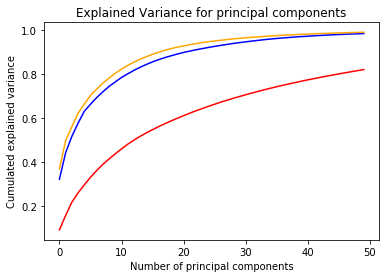

In [23]:
plt.plot(np.cumsum(ms_explained_var), color="blue")
plt.plot(np.cumsum(mfcc_explained_var), color="red")
plt.plot(np.cumsum(cqt_explained_var), color="orange")
plt.xlabel('Number of principal components')
plt.ylabel('Cumulated explained variance')
plt.title('Explained Variance for principal components')
plt.show()

### TSNE

In [24]:
from sklearn.manifold import TSNE

tsne_ms = TSNE(n_components=2).fit_transform(pca_ms)
tsne_mfcc = TSNE(n_components=2).fit_transform(pca_mfcc)
tsne_cqt = TSNE(n_components=2).fit_transform(pca_cqt)

tsne_ms.shape, tsne_mfcc.shape, tsne_cqt.shape

((5073, 2), (5073, 2), (5073, 2))

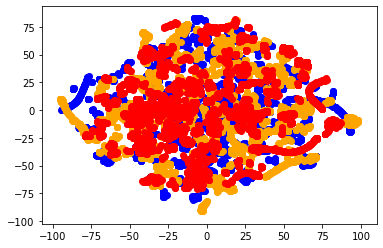

In [25]:
plt.scatter(tsne_ms.T[0], tsne_ms.T[1], color="blue")
plt.scatter(tsne_mfcc.T[0], tsne_mfcc.T[1], color="orange")
plt.scatter(tsne_cqt.T[0], tsne_cqt.T[1], color="red")

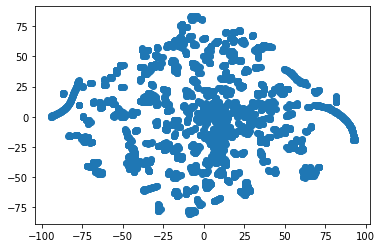

In [26]:
plt.scatter(tsne_ms.T[0], tsne_ms.T[1])

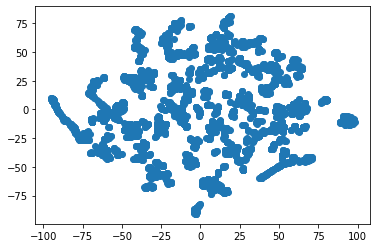

In [27]:
plt.scatter(tsne_mfcc.T[0], tsne_mfcc.T[1])

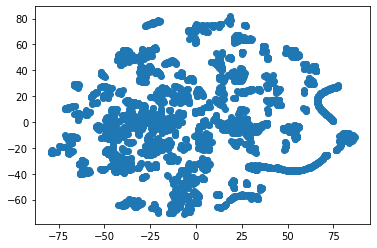

In [28]:
plt.scatter(tsne_cqt.T[0], tsne_cqt.T[1])

# Training data

## Classical ML Algorithms

## Deep Learning Algorithms

## Using Transformers (Speech to Text adapt)

# Results and evaluation